# OIL WELL DETECTION MODEL

# Variable information

* JUS = jusante = downstream
* MON = montante = upstream
* CKP = choke de produção = production choke
* CKGL = choke de gas lift = gas lift choke

1. Pressure at the Permanent Downhole Gauge — deep inside the well <strong>(P-PDG)</strong>;
2. Pressure at the Topside Pressure Transducer — at surface level <strong>(P-TPT)</strong>;
3. Temperature at the Topside Pressure Transducer <strong>T-TPT</strong>;
4. Pressure upstream of the Production Choke <strong>P-MON-CKP</strong>;
5. Temperature downstream of the Production Choke <strong>T-JUS-CKP</strong>;
6. Pressure downstream of the Gas Lift Choke <strong>P-JUS-CKGL</strong>;
7. Temperature downstream of the Gas Lift Choke <strong>T-JUS-CKGL</strong>;
8. Gas Lift Flow Rate — volume of gas being injected <strong>QGL</strong>;






### Understanding Basic Terms
An oil well is essentially a pipe going deep underground. Oil and gas are trapped in rock thousands of meters below. The challenge is getting it to the surface in a controlled way.

<hr>
Downhole Gauge (PDG)
A sensor sitting deep inside the well, close to where the oil actually is. It measures pressure at the source. Think of it as taking the pulse of the reservoir itself. "Downhole" just means underground, inside the well bore.

<hr>
Transducer (TPT)
A transducer is just a device that converts a physical property (like pressure or temperature) into an electrical signal you can record. TPT sits at the top of the well, at surface level. "Topside" means above ground. So P-PDG and P-TPT are both measuring pressure, just one is deep underground and one is at the surface.

<hr>
Production Choke (CKP)
Oil and gas coming up the well is under enormous pressure. You can't just let it blast out freely — it would be dangerous and uncontrollable. The production choke is essentially an adjustable valve that restricts the flow, controlling how fast oil comes out. Think of it like a tap. Measuring pressure before (upstream) and after (downstream) the choke tells you how much pressure is being lost across it, which reveals if something is wrong with flow.

<hr>
Gas Lift Choke (CKGL)
Sometimes a well doesn't have enough natural pressure to push oil to the surface on its own. Gas lift solves this by injecting gas down into the well, which lightens the column of fluid and helps push oil up — like blowing air into a straw submerged in water. The gas lift choke controls how much of that injected gas goes in. QGL is literally measuring how much gas is flowing through this choke.

In [3]:
class_labels = {
    0: "Normal Operation",
    1: "Abrupt Increase of BSW",
    2: "Incipient Leak in Production Choke",
    3: "Flow Instability",
    4: "Rapid Productivity Loss",
    5: "Quick Restriction in Production Choke",
    6: "Scaling in Production Choke",
    7: "Hydrate in Production Line",
    8: "Hydrate in Service Line",

    101: "Transient - Abrupt Increase of BSW",
    102: "Transient - Incipient Leak in Production Choke",
    103: "Transient - Flow Instability",
    104: "Transient - Rapid Productivity Loss",
    105: "Transient - Quick Restriction in Production Choke",
    106: "Transient - Scaling in Production Choke",
    107: "Transient - Hydrate in Production Line",
    108: "Transient - Hydrate in Service Line",
}

### undertsanding classes
After reviewing the data again, I sort to look at the faults in depth and learn how these faults might affect the sensors.

<strong>Class 0 — Normal Operation</strong>
The well is producing steadily. Reservoir pressure drives oil up through the wellbore, through the production choke, into the pipeline. All sensors are stable with low variance. P-TPT and P-MON-CKP hold steady, temperatures are consistent. This is your baseline — every fault class is defined by how it deviates from this state.
<hr>

<strong>Class 1 — Abrupt Increase of BSW (Basic Sediment & Water)</strong>
BSW is the percentage of water and sediment mixed into the produced oil. Normally a well produces mostly oil with some water. In this fault, water suddenly breaks through from the reservoir in large quantities.
What happens physically: The reservoir has an oil zone sitting on top of a water zone. Over time, or due to production strategy, water breaks through into the wellbore. Suddenly you're pumping mostly water instead of oil.
Sensor signature:

* P-PDG drops — water is heavier than oil, changing the pressure gradient
* Temperature changes — water has different thermal properties than oil
* The transition is abrupt, not gradual

Why it matters: Water is corrosive, damages downstream equipment, reduces production value dramatically, and increases processing costs.
<hr>

<strong>Class 2 — Incipient Leak in Production Choke</strong>
A small, developing crack or seal failure in the production choke valve — before it becomes a full rupture.
What happens physically: The choke valve body or seat develops a small leak, allowing fluid to bypass the controlled flow path. Flow is no longer fully controlled by the valve position.
Sensor signature:

* P-MON-CKP (upstream pressure) behaves unexpectedly relative to choke position
* Flow rate becomes inconsistent with expected values
* The pressure differential across the choke changes subtly

Why it matters: A small leak escalates into a full choke failure if undetected. Choke replacement offshore is extremely expensive and requires production shutdown.
<hr>

<strong>Class 3 — Flow Instability</strong>
The well flow oscillates in cyclic patterns instead of flowing steadily. Also called slugging.
What happens physically: Oil and gas don't flow as a uniform mixture. Instead they segregate — gas accumulates, builds pressure, then releases suddenly pushing a slug of liquid through the pipe. This creates a repeating cycle of high flow/low flow.
Sensor signature:

This is the most periodic fault — all sensors oscillate rhythmicall:
* P-TPT and P-MON-CKP show regular peaks and troughs
* Temperature oscillates in sync with pressure
* Std and variance features will be very high for this class

Why it matters: Slugging causes severe mechanical stress on equipment, damages compressors and separators downstream, and makes production measurement unreliable.

<hr>

<strong>Class 4 — Rapid Productivity Loss</strong>
The well suddenly starts producing significantly less oil than expected given the operating conditions.
What happens physically: Several possible causes — reservoir damage near the wellbore (skin damage), scale or wax deposition deep in the well, or a sudden change in reservoir connectivity. The well loses its ability to deliver fluid efficiently.
Sensor signature:

* QGL increases as operators inject more gas lift to compensate
* P-PDG drops as reservoir deliverability falls
* P-TPT drops as less fluid reaches the surface
* The decline is rapid — happening over hours not weeks

Why it matters: Directly impacts production revenue. Early detection allows intervention before permanent reservoir damage occurs.

<hr>

<strong>Class 5 — Quick Restriction in Production Choke</strong>
Something partially blocks the production choke suddenly — reducing the flow opening without the operator changing the choke setting.
What happens physically: Debris, wax, scale, or a mechanical failure partially closes the choke. The effective flow area shrinks suddenly.
Sensor signature:

* P-MON-CKP (upstream of choke) increases — pressure builds up behind the restriction
* P-TPT (downstream/topside) decreases — less fluid getting through
* The pressure differential across the choke increases sharply
* This pressure differential (P-MON-CKP minus P-TPT) is potentially a very powerful engineered feature for this class specifically

Why it matters: Reduces production rate, can escalate to complete blockage, and puts mechanical stress on the choke.

<hr> 

<strong>Class 6 — Scaling in Production Choke</strong>
Mineral deposits (scale) slowly build up inside the production choke, gradually narrowing the flow path.
What happens physically: Produced water contains dissolved minerals — calcium carbonate, barium sulphate etc. As conditions change (pressure drop, temperature change) across the choke, these minerals precipitate out and deposit on the choke walls. Unlike class 5 this is a slow, progressive restriction.
Sensor signature:

Similar to class 5 but develops gradually over days/weeks not suddenly
* P-MON-CKP slowly increases over time
* Slope features are particularly important here — slow upward trend in upstream pressure
* Std remains relatively low because the change is gradual not erratic

Why it matters: If undetected, scaling completely blocks the choke requiring expensive intervention. Chemical treatment is cheap if caught early.

<hr>

<strong>Class 7 — Hydrate in Production Line</strong>
Ice-like crystals form inside the production pipeline and start blocking flow.
What happens physically: Natural gas + water + high pressure + low temperature = hydrates. They look like ice but form at temperatures well above 0°C under pressure. They can block a pipeline completely within hours.
Sensor signature:

* Temperature is the critical sensor — T-TPT and T-JUS-CKP drop toward the hydrate formation temperature
* Pressure upstream of the blockage increases as the hydrate grows
* Pressure downstream drops as flow is restricted
* QGL often increases as operators try to maintain flow
  
Month/season is a strong predictor — hydrates form more easily in cold months

Why it matters: Hydrate plugs are one of the most dangerous and costly problems in offshore production. Clearing a hydrate plug can take days and costs millions.

<hr> 

<strong>Class 8 — Hydrate in Service Line</strong>
Same hydrate physics as class 7 but occurring in the gas lift injection line rather than the production line.
What happens physically: The gas being injected for gas lift is cold and high pressure — ideal hydrate formation conditions. As it travels down the service line to the injection point, hydrates can form and block the gas lift system.
Sensor signature:

* P-JUS-CKGL drops or becomes erratic — gas lift pressure is disrupted
* QGL drops — less gas getting through to the injection point
* The production line sensors (P-TPT, P-MON-CKP) then react secondarily as gas lift effectiveness drops
* T-JUS-CKGL would have been the primary indicator — but that's your missing sensor

Why it matters: When gas lift is blocked, wells with insufficient natural pressure stop producing entirely. Losing gas lift = losing production.

## Importing Libraries 📚

In [1]:
# Import libraries and packages. 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pathlib as Path

In [2]:
# Load merged datsaset
df = pd.read_csv("../data/training_set1.csv")

In [3]:
df.drop(columns="Unnamed: 0", inplace=True)

In [4]:
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

## Stage 1: Clean dataset
* Analyse data
* Handle missing values
* Handle NaN Values
* Feature engineering

###  Observation 1:
1. T-JUS-CKP (762990) which has no values, That means the temperature sensor simply wasn't installed on any of these wells. There is no data to validate any estimate against, hence the column will be dropped.

2. P-JUS-CKGL (609,594 missing values), Here the NaN means something structurally different from a normal missing value — it means the gas lift was simply switched off at that time. It's not a sensor failure, it's an operational state. Putting the NaN values as 0 will be the next step to go while creating a new column called "gas_lift_active" to show the model the relationship between the 0 values in P-JUS-CKGL and the gas choke being inactive/active.

QGL is the flow rate of gas being injected — how much gas is moving.
P-JUS-CKGL is the pressure measured downstream of the gas lift choke — what pressure that gas creates after passing through.
Physically, the relationship is:

If QGL = 0 (no gas flowing), then P-JUS-CKGL should also be 0 or negligible
But if P-JUS-CKGL has a value, gas must be flowing, so QGL should also have a value

The fact that QGL has more non-NaN values than P-JUS-CKGL suggests the pressure sensor (P-JUS-CKGL) was simply not installed on some wells, while the flow meter (QGL) was. It's a sensor availability issue, not an operational one.

So the hierarchy is:
QGL is the more reliable indicator of gas lift activity because:

* Flow rate is the direct measure of whether gas is actually being injected
* Pressure downstream can sometimes read a residual value even when flow is minimal
* More wells had the QGL meter installed than the pressure sensor

In [5]:
# Remove T-JUS-CKGL 
df = df.drop(columns="T-JUS-CKGL")

In [6]:
# Fill missing values of P-JUS-CKGL & QGL with	0
df["gas_lift_active"] = df["QGL"].notna().astype(int) # if gas QGL (flow rate) has a value, then the gas lift was active

In [7]:
df["QGL"] = df["QGL"].fillna(0) # Fill NaN values with 0
df["P-JUS-CKGL"] = df["P-JUS-CKGL"].fillna(0)

In [8]:
df.isna().sum()

timestamp              0
P-PDG              75713
P-TPT                  3
T-TPT              50000
P-MON-CKP              0
T-JUS-CKP              3
P-JUS-CKGL             0
QGL                    0
class                  0
gas_lift_active        0
dtype: int64

###  Observation 2:
P-MON-CKP (1557) and T-JUS-CKP (10416) 

P-MON-CKP and T-JUS-CKP measure the oil flow itself, not the choke hardware. The choke is just a valve — it doesn't generate pressure or temperature, it just controls how much fluid passes through. So what you're measuring is the oil/gas mixture's pressure before it hits the choke (P-MON-CKP) and its temperature after passing through (T-JUS-CKP).
If the values are NaN, it doesn't mean the choke wasn't installed — every producing well must have a production choke, otherwise you can't control the flow at all. NaN here most likely means the sensor was faulty, offline, or not logged during that period. It's not an operational state like with gas lift. So these NaN rows should be treated as genuinely missing data — either impute or drop.


Hence, these missing values will be dropped


In [9]:
# Drop NaN rows from P-MON-CKP and T-JUS-CKP
df = df.dropna(subset=["P-MON-CKP", "T-JUS-CKP"])

###  Observation 3:
The final column T-TPT is the temperature reading in electrical signals of the natural gas. these signals are gotten from the tranducer, which displays also the pressure of the gas. Since, the pressure is being read, it would most likely be a sensor failure. 

In the case where it isn't a sensory failure it can be because the temperature exceeds the calibrated range (too hot or too cold), the sensor might stop sending valid data


The data will be checked for the temperature at the downstream of the Gas Lift Choke (T-JUS-CKP) to check if the temperature was too hot at the time.

In [10]:
temperature_check_cold = df.loc[(df["T-TPT"].isna()) & (df["T-JUS-CKP"] < 10), ["timestamp","T-JUS-CKP"]]
temperature_check_cold

,timestamp,T-JUS-CKP


In [11]:
temperature_check_hot = df.loc[(df["T-TPT"].isna()) & (df["T-JUS-CKP"] > 100), ["timestamp","T-JUS-CKP"]]
temperature_check_hot

,timestamp,T-JUS-CKP


In [12]:
df["T-TPT"] = df["T-TPT"].ffill() 

we see that there is no reason to believe out of range theory. it is sensory failure. hence, we either drop the values or forward fill. Forward-fill T-TPT using the last valid reading. This makes physical sense because temperature at the topside transducer changes slowly and gradually — it doesn't jump suddenly. A forward-fill preserves the last known valid state which is a reasonable approximation.

###  Observation 4:
Since P-PDG has just 50 NaN rows, it will be removed.


Notice the P-PDG Column has a lot of zeros (not NaN) and this might be bad. let me explain:


The P-PDG is the downhole gauge, sitting deep inside the well. Unlike surface sensors, it's in an extremely harsh environment — high pressure, high temperature, constant vibration, corrosive fluids. It is by far the most failure-prone sensor in the entire setup because:

It's physically inaccessible — you can't just swap it out without a workover operation which is expensive
The electrical cable running from deep underground to the surface degrades over time
Power supply interruptions to the downhole tool would cause it to read exactly 0, not NaN — because 0 is the default output when the tool loses power or signal

So a reading of 0 while everything else is normal and class = 0 points strongly to one of two things:

Dead sensor — the PDG lost power or the cable failed, defaulting to 0 output. The well kept producing normally, surface sensors kept reading correctly, operators just lost their downhole visibility
Sensor turned off deliberately — sometimes operators disable the downhole gauge for maintenance or calibration while the well stays online



<strong>Solution?</strong>

The columns will be treated as NaN values (replace 0 with NaN), then i will forward fill and backward fill the values. This is more honest than leaving 0 in there — a 0 bar downhole pressure would confuse your model badly since it looks like a dramatic pressure drop when it isn't one. But this would be done in the `process_file()` function, so we wont get a pressure from another class (i.e a fault) which will spoil our data.


I noticed that for a whole class (like class 0) the P-PDG reading was 0. so it cannot ffill or bfill(). Those rows were removed.

In [13]:
df = df.dropna(ignore_index=True)
df.isna().sum()

timestamp          0
P-PDG              0
P-TPT              0
T-TPT              0
P-MON-CKP          0
T-JUS-CKP          0
P-JUS-CKGL         0
QGL                0
class              0
gas_lift_active    0
dtype: int64

#### Feature engineering

##### 1. Convert the pressure columns to Pascal to scale down values

In [14]:
bar_equivalent = 0.00001   # standard unit

pressure_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']

df[pressure_cols] = df[pressure_cols] * bar_equivalent

In [15]:
# Rearrange columns so class can be the last column to the right
df = df[["timestamp", "P-PDG", "P-TPT", "T-TPT", "P-MON-CKP", "T-JUS-CKP", "P-JUS-CKGL", "QGL", "gas_lift_active", "class"]]

##### 2. Extracting Information from timestamp
Month will be extracted from the timestamp column since weather periods happen in paritcular months, which might affect temperature. Hydrate formation (classes 7 and 8) is strongly temperature-dependent — hydrates form more easily in cold months. BSW increases (class 1) can also correlate with seasonal water influx patterns. So month carries real domain signal, not just arbitrary time information.


<strong>Note from Claude:</strong>
month is a cyclical feature. January (1) and December (12) are actually close together seasonally but numerically they're far apart. A model treating them as 1 and 12 on a linear scale gets confused. The standard fix is to encode month as sine and cosine:

In [16]:
df["month"] = df["timestamp"].dt.month

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df = df.drop(columns=["month"])

##### 3. Adding rolling window feature
This will be done to get more information on the data like the std, variance, range and mean.

* STD : Tells the model how far the data point is from the mean, a high std means the pressure (for example) spiked from the normal/average pressure. For fault detection this is arguably the most powerful feature. A pressure that is normally std=0.2 suddenly jumping to std=3.0 is a red flag, even before the mean shifts significantly.
* MEAN: This is the average value over the past window. shows the average value over that time period. If this starts drifting lower over successive windows, something is changing in the well.
* VARIENCE : std squared. Carries the same information as std but amplifies larger deviations because of the squaring. A deviation of 2 contributes 4 to variance, a deviation of 5 contributes 25 = 1.14 bar².
* RANGE: Max - Min. Small range value shows there is no sudden change or spike.
* EWN (Exponential weighting): The most recent row gets the most weight. Weight decays exponentially as you go further back. This is very useful for sensor data because it means the most recent reading matters most — which makes physical sense. A pressure reading from 10 minutes ago is less relevant than the reading from 1 minute ago.

In [17]:
for col in ['P-PDG','P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL']:
    df[f"{col}_mean"] = df[col].rolling(window=10, min_periods=1).mean()  # Mean column 10minutes period
    df[f"{col}_mean"] = df[col].rolling(window=120, min_periods=1).mean().bfill()  # Mean column 2hr period
    df[f"{col}_var"] = df[col].rolling(window=10, min_periods=1).var().fillna(0)  # Varience column
    df[f"{col}_std"] = df[col].rolling(window=10, min_periods=1).std().fillna(0)  # Standard derivation 10 minute period
    df[f"{col}_std"] = df[col].rolling(window=120, min_periods=1).std().bfill()  # Standard derivation 2 hr period
    df[f"{col}_range"] = df[col].rolling(window=10, min_periods=1).apply(lambda x : max(x) - min(x))  # Range column

for col in ['P-PDG','P-TPT', 'P-MON-CKP', 'P-JUS-CKGL', 'QGL']:
    df[f"{col}_ewm"] = df[col].ewm(span=10).mean()  # EWM for pressure columns

##### 4. Feature combinations

In [18]:
'''
In a healthy well, downhole pressure is always higher than topside. 
This ratio should always be greater than 1. When it drops below 1 something is wrong. 
Clip it between 0 and 1 for stability:
'''
df["P-PDG_P-TPT_ratio"] = (df["P-PDG"] / (df["P-TPT"] + 1)).clip(0,1)


'''
When water breaks through, temperature and pressure decouple — pressure drops while temperature
shifts independently. The ratio of temperature to pressure captures this divergence:
'''
df["T_P_divergence"] = df["T-TPT"] / (df["P-TPT"] + 1)

'''
A leaking choke loses its ability to maintain the pressure difference between upstream and downstream. 
The differential should be large and stable during normal operation — a leak causes it to collapse or fluctuate:


Std captures fluctuation — but std and this differential capture different things. Std tells you how much it's moving. 
The differential tells you the absolute magnitude of the pressure drop across the choke. Both matter.
'''
df['choke_pressure_diff'] = df['P-MON-CKP'] - df['P-TPT']

'''
Claude suggested this: Slugging creates rhythmic oscillations. The rolling std already captures this but a 
direct measure of oscillation — how much pressure reverses direction within a window — adds something different

This counts how many times the pressure reverses direction in the last 10 minutes. 
High sign changes = oscillating = slugging. Normal flow = near zero sign changes.

'''
df['P_TPT_diff'] = df['P-TPT'].diff().bfill()
df['P_TPT_sign_changes'] = df['P_TPT_diff'].rolling(10, min_periods=1).apply(
    lambda x: ((x[:-1] * x[1:]) < 0).sum()
).bfill()

'''
When a well loses productivity, operators instinctively increase gas lift to compensate. 
So QGL rises while P-TPT falls — the ratio captures this inverse relationship (for class 4)
'''
df['productivity_index'] = df['P-TPT'] / (df['QGL'] + 1)

'''
Claude suggested this: Scaling builds slowly over days. A short 10-minute rolling window misses this. 
A longer window slope will be added specifically for upstream choke pressure (for class 6)
'''
df['P_MON_CKP_slope_60'] = df['P-MON-CKP'].rolling(60, min_periods=10).apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0]
).bfill()

'''
Claude suggested this: Hydrates form when temperature drops toward a threshold — roughly 15–20°C at typical well pressures. 
Distance from that danger zone is the key signal:
'''
df['hydrate_risk'] = df['T-JUS-CKP'] - 20  # distance from hydrate threshold

In [19]:
# 60  minute rolling window.
df['P_TPT_std_60'] = df['P-TPT'].rolling(60, min_periods=1).std().bfill()
df['T_TPT_std_60'] = df['T-TPT'].rolling(60, min_periods=1).std().bfill()

# Creating stable Temp and Pressure column
df['all_stable'] = (
    (df['P-TPT'].between(80, 140)) &
    (df['T-TPT'].between(50, 130)) &
    (df['P-MON-CKP'].between(10, 50))
).astype(int)

# Stability streak finding the stabe
df['stability_streak'] = df['all_stable'].groupby( 
    (df['all_stable'] != df['all_stable'].shift()).cumsum()
).cumcount()

'''
This finds the stability of the sensor values. 
it firsts shifts the values of the "all_stable" once, and compares it with the original "all_stable" column 
and adds up the True values cumulatively. Every time a change is detected, the group number increments. 
This creates a unique group ID for each consecutive run. Within each group, 
cumcount() counts how many rows have passed since the group started. Starts at 0:
'''

'\nThis finds the stability of the sensor values. \nit firsts shifts the values of the "all_stable" once, and compares it with the original "all_stable" column \nand adds up the True values cumulatively. Every time a change is detected, the group number increments. \nThis creates a unique group ID for each consecutive run. Within each group, \ncumcount() counts how many rows have passed since the group started. Starts at 0:\n'

## STAGE 2: VISUALISATION

In [20]:
 df.to_csv("../data/cleaned_dataset.csv",index_label=False)

Visualisation done in the visualise notebook.


## STAGE 3: PREPROCESSING

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, RocCurveDisplay, f1_score, recall_score, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from sklearn.tree import plot_tree

In [22]:
'''
Processing function to clean and feature engineer testing dataset
'''
def preprocessing(df):
    if df.isna().any(axis=None):
        # Remove T-JUS-CKGL 
        df = df.drop(columns=["T-JUS-CKGL","Unnamed: 0"])
        
        # Fill missing values of P-JUS-CKGL & QGL with	0
        df["gas_lift_active"] = df["QGL"].notna().astype(int)
        
        # Fill NaN values with 0
        df["QGL"] = df["QGL"].fillna(0)
        df["P-JUS-CKGL"] = df["P-JUS-CKGL"].fillna(0)
    
        # Drop NaN rows from P-MON-CKP and T-JUS-CKP
        df = df.dropna(subset=["P-MON-CKP", "T-JUS-CKP"])
        
        if df["T-TPT"].isna().any(axis=None):
            df["T-TPT"] = df["T-TPT"].ffill() 

        df = df.dropna(ignore_index=True)
        
        # Convert to bar
        bar_equivalent = 0.00001   # standard unit
        pressure_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']
        df[pressure_cols] = df[pressure_cols] * bar_equivalent

        # Rearrange columns so class can be the last column to the right
        df = df[["timestamp", "P-PDG", "P-TPT", "T-TPT", "P-MON-CKP", "T-JUS-CKP", "P-JUS-CKGL", "QGL", "gas_lift_active", "class"]]

        df["month"] = df["timestamp"].dt.month

        df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
        df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

        df = df.drop(columns=["month"])

        # Extract datetime information and drop column in preparation for fitting model
        df = df.drop(columns="timestamp")

        for col in ['P-PDG','P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL']:
            df[f"{col}_mean"] = df[col].rolling(window=10, min_periods=1).mean()  # Mean column 10minutes period
            df[f"{col}_mean"] = df[col].rolling(window=120, min_periods=1).mean().bfill()  # Mean column 2hr period
            df[f"{col}_var"] = df[col].rolling(window=10, min_periods=1).var().fillna(0)  # Varience column
            df[f"{col}_std"] = df[col].rolling(window=10, min_periods=1).std().fillna(0)  # Standard derivation 10 minute period
            df[f"{col}_std"] = df[col].rolling(window=120, min_periods=1).std().bfill()  # Standard derivation 2 hr period
            df[f"{col}_range"] = df[col].rolling(window=10, min_periods=1).apply(lambda x : max(x) - min(x))  # Range column

        for col in ['P-PDG','P-TPT', 'P-MON-CKP', 'P-JUS-CKGL', 'QGL']:
            df[f"{col}_ewm"] = df[col].ewm(span=10).mean()  # EWM for pressure columns

        
        df["P-PDG_P-TPT_ratio"] = (df["P-PDG"] / (df["P-TPT"] + 1)).clip(0,1)
        
        df["T_P_divergence"] = df["T-TPT"] / (df["P-TPT"] + 1)
        
        df['choke_pressure_diff'] = df['P-MON-CKP'] - df['P-TPT']
        
        df['P_TPT_diff'] = df['P-TPT'].diff().bfill()
    
        df['P_TPT_sign_changes'] = df['P_TPT_diff'].rolling(10).apply(
            lambda x: ((x[:-1] * x[1:]) < 0).sum()
        ).bfill()
        
        df['productivity_index'] = df['P-TPT'] / (df['QGL'] + 1)
        
        df['P_MON_CKP_slope_60'] = df['P-MON-CKP'].rolling(60, min_periods=10).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0]
        ).bfill()
        
        df['hydrate_risk'] = df['T-JUS-CKP'] - 20  # distance from hydrate threshold

        # 60  minute rolling window.
        df['P_TPT_std_60'] = df['P-TPT'].rolling(60, min_periods=1).std().bfill()
        df['T_TPT_std_60'] = df['T-TPT'].rolling(60, min_periods=1).std().bfill()
        
        # Creating stable Temp and Pressure column
        df['all_stable'] = (
            (df['P-TPT'].between(80, 140)) &
            (df['T-TPT'].between(50, 130)) &
            (df['P-MON-CKP'].between(10, 50))
        ).astype(int)
        
        # Stability streak finding the stabe
        df['stability_streak'] = df['all_stable'].groupby( 
            (df['all_stable'] != df['all_stable'].shift()).cumsum()
        ).cumcount()
                
        
        if df.isna().any(axis=None):
            print(f"Missing values still detected")
            return df
        else:
            print(f"Dataframe preprocessed successfully")
            return df
    else:
        print(f"No Missing data")
        return df

In [23]:
# Load test data
test_df = pd.read_csv('../data/test_set1.csv')
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])


# Pass it through the preprocessing fucntion
test_df_cleaned = preprocessing(test_df)

Dataframe preprocessed successfully


In [25]:
test_df_cleaned.to_csv("../data/test_set1_cleaned.csv", index=False)

## STAGE 5 : SPLIT DATA

In [ ]:
# Split dataset into X and y
X_train = df.drop(columns=["class","timestamp"])
y_train = df["class"]


X_test = test_df_cleaned.drop(columns=["class"])
y_test = test_df_cleaned["class"]

## STAGE 6 : APPLY SMOTE TO IMBALANCED DATASET

In [ ]:
from imblearn.over_sampling import BorderlineSMOTE, SMOTE

In [ ]:
# Step 1 — SMOTE builds interior samples
smote = SMOTE(
    sampling_strategy = {
        7.0: 7000,    # bring class 7 from 1,712 to 8,000
        102.0: 7000,  # bring class 102 from 996 to 6,000
        2.0: 7000,    # bring class 2 from 5,784 to 8,000
        108.0: 20000  # bring class 108 up
    },
    k_neighbors=5,
    random_state=42
)

X_smote, y_smote = smote.fit_resample(X_train,y_train)

# Step 2 — BorderlineSMOTE reinforces the boundary
bsmote = BorderlineSMOTE(
    sampling_strategy={
        7.0: 8000,   # push class 7 further to 15,000
        102.0: 8000, # push class 102 to 10,000
        2.0: 8000,   # push class 2 to 15,000
        108.0: 30000  # push class 108 further
    },
    k_neighbors=5,
    random_state=42
)
X_train_resampled, y_train_resampled = bsmote.fit_resample(X_smote, y_smote)

## STAGE 7 : TRAIN MODEL

#### 1. RandomForest

In [ ]:
clf_1 = RandomForestClassifier(n_estimators=300,class_weight="balanced", n_jobs=-1)

In [ ]:
# Using RandomForestClassifier
clf_1.fit(X_train_resampled,y_train_resampled)

# get accuracy scoring
clf_score_1 = clf_1.score(X_test,y_test) 

# get recall score
y_preds_clf_1 = clf_1.predict(X_test)
recall_score_1= recall_score(y_test, y_preds_clf_1, average="weighted")

# print scores
print("===================================================================")
print(f"Recall scoring is {recall_score_1} /n and Accuracy is {clf_score_1}")

Recall scoring is 0.8298682372636919 /n and Accuracy is 0.8298682372636919


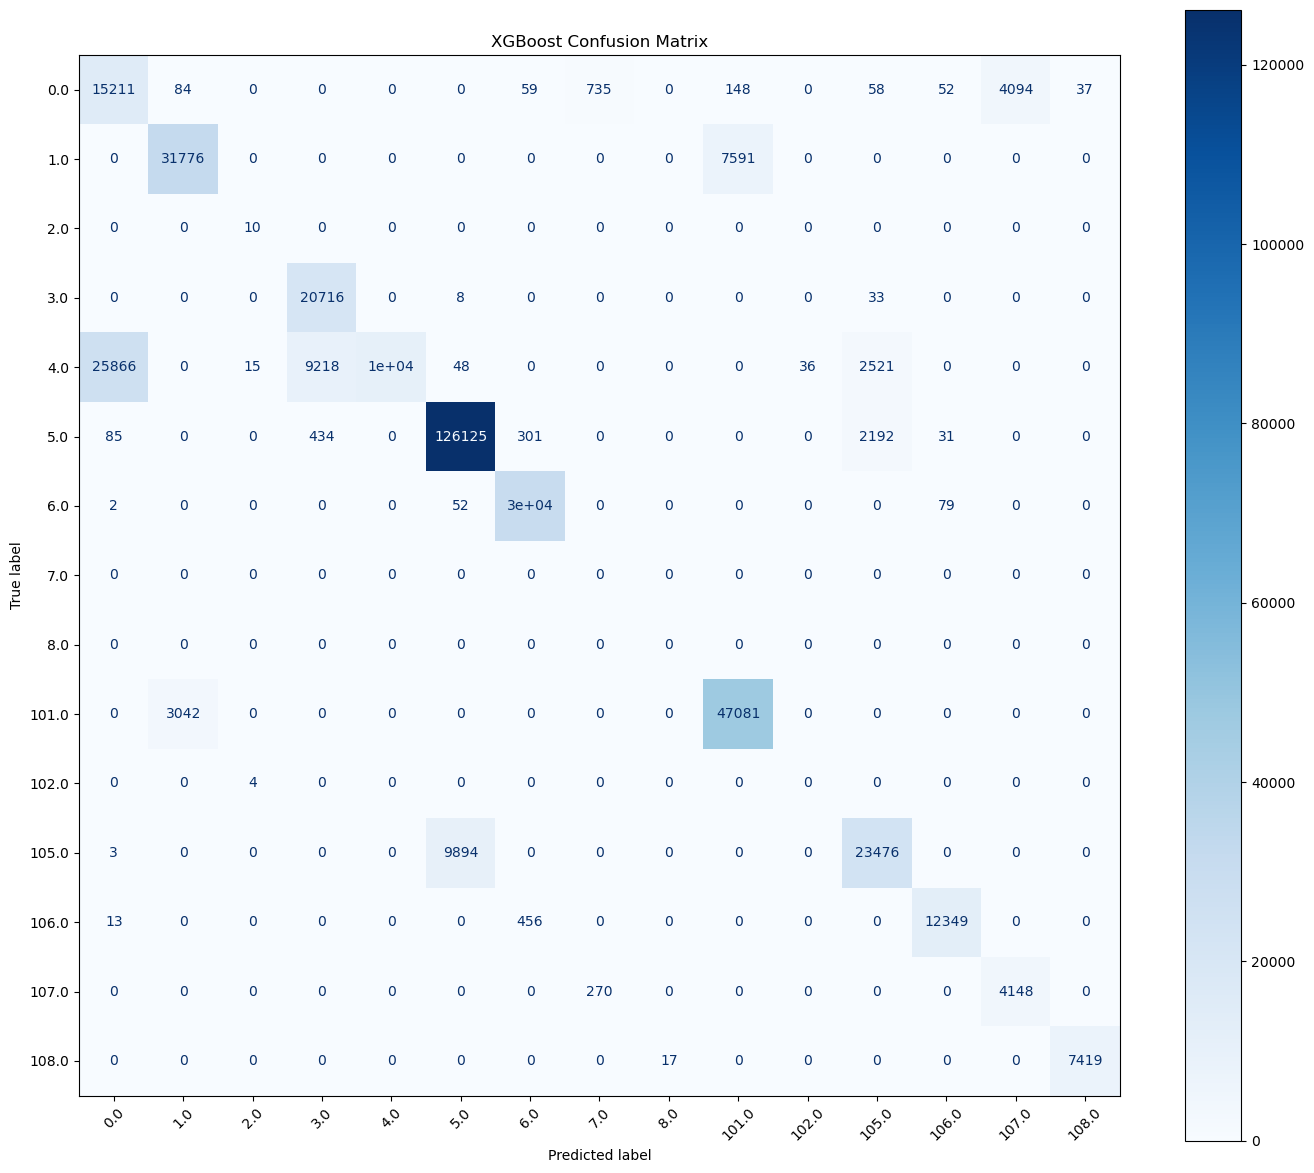

In [ ]:
y_preds = clf_1.predict(X_test)

cfm = confusion_matrix(y_preds, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cfm, display_labels=clf_1.classes_)
fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=45)
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=130, bbox_inches='tight')

<strong>Classification report with Random Forest</strong>

In [ ]:
# Creating classification report
y_preds_1 = clf_1.predict(X_test)
report_dict = classification_report(y_test, y_preds_1, output_dict=True,)

class_report_1 = pd.DataFrame(report_dict).transpose()
class_report_1.to_csv("../data/class_report_1.csv")
class_report_1

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

,precision,recall,f1-score,support
0.0,0.742797,0.369378,0.493399,41180.000000
1.0,0.807174,0.910435,0.855700,34902.000000
2.0,1.000000,0.344828,0.512821,29.000000
3.0,0.998025,0.682165,0.810406,30368.000000
4.0,0.215595,1.000000,0.354715,10363.000000
5.0,0.976442,0.926524,0.950828,136127.000000
6.0,0.995654,0.973918,0.984666,31286.000000
7.0,0.000000,0.000000,0.000000,1005.000000
8.0,0.000000,0.000000,0.000000,17.000000
101.0,0.939309,0.858829,0.897268,54820.000000


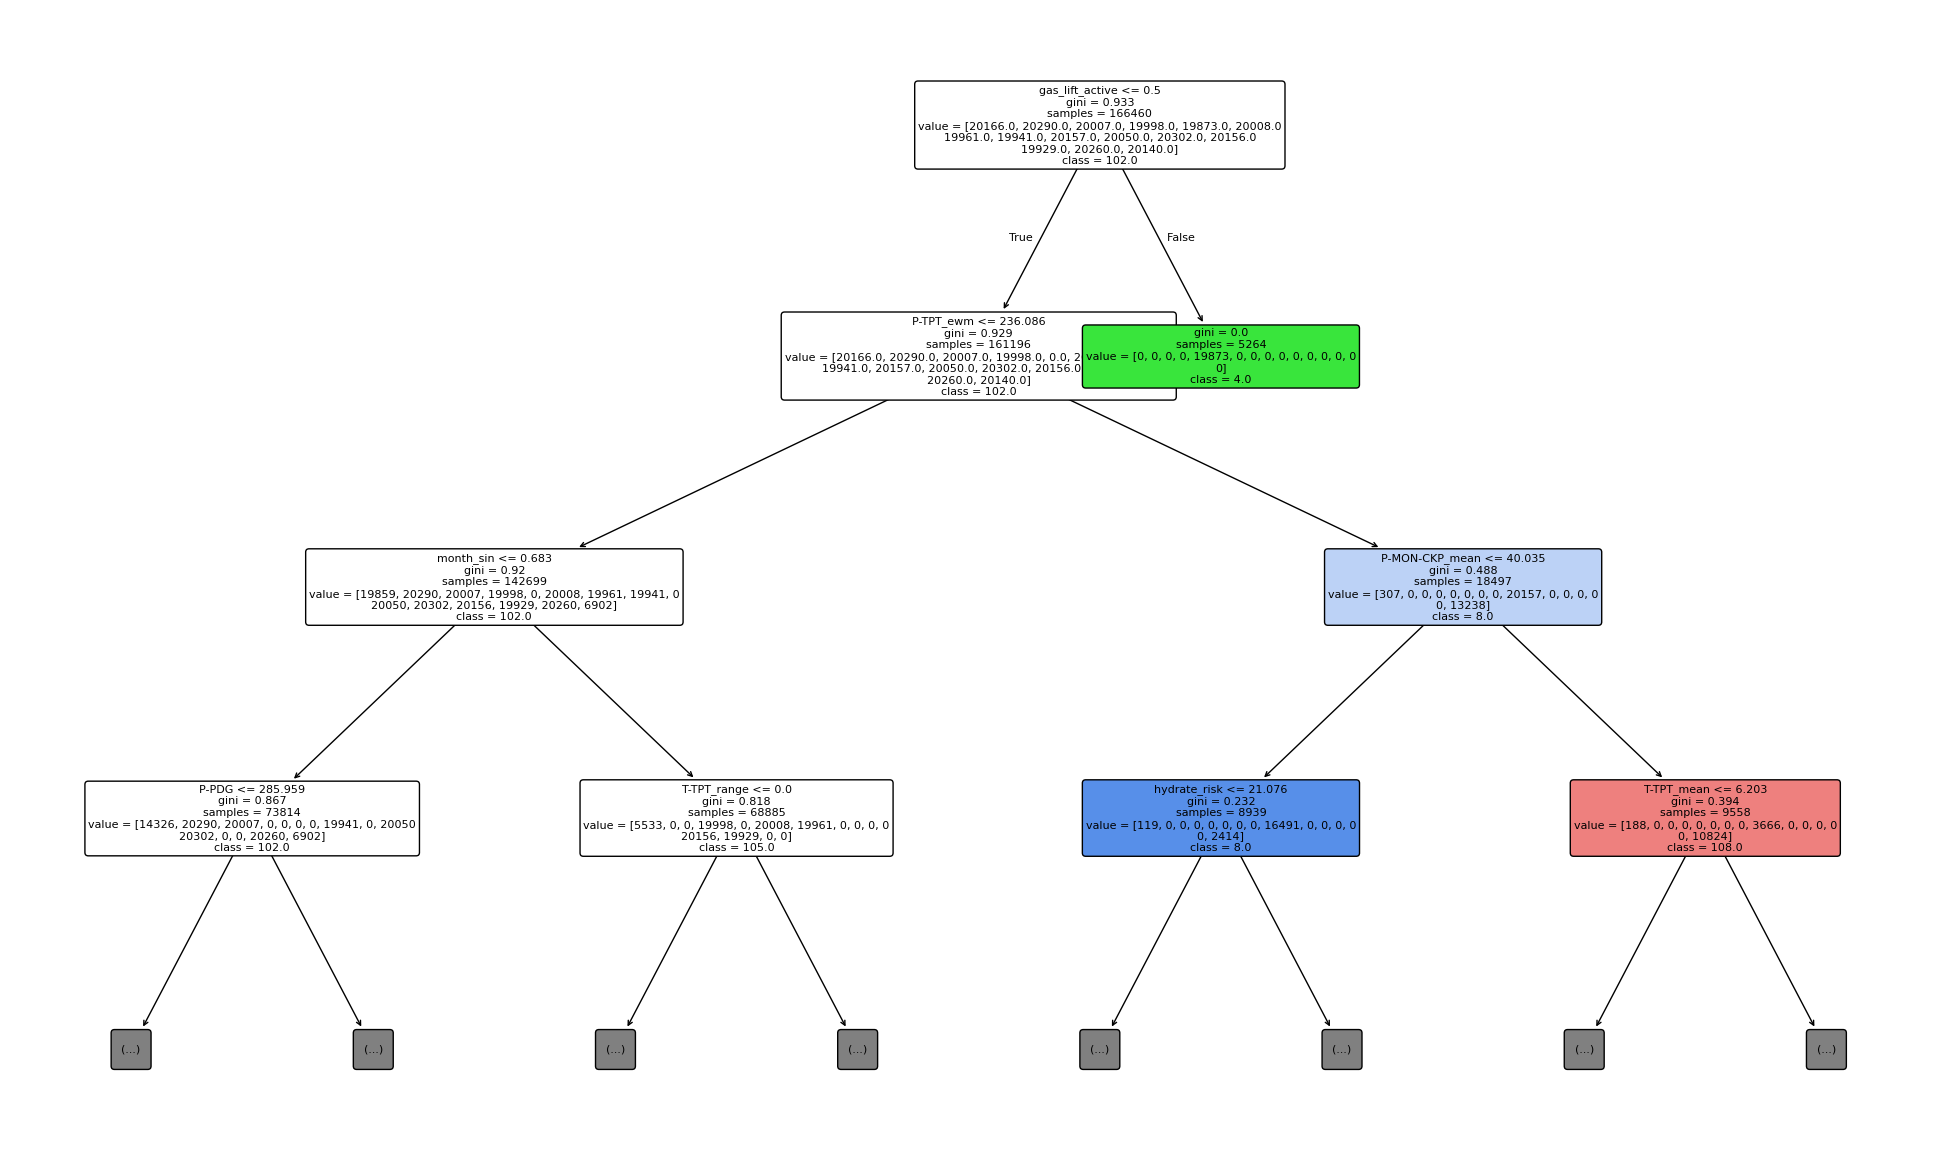

In [ ]:
tree = clf_1.estimators_[0]

plt.figure(figsize=(25, 15))

plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=[str(c) for c in clf_1.classes_],
    filled=True,
    rounded=True,
    max_depth=3, 
    fontsize=8
)

plt.show()

#### 2. XGBoost

In [ ]:
# Xgb requires some extra hyperparameter tuning. 
# First, for our imbalanced dataset, compute_sample_weight would be ran to penalize wrongly predicted values on classes with smaller rows like class 7
from sklearn.utils.class_weight import compute_sample_weight


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled)
y_test_encoded = le.transform(y_test)

weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

clf_2 = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    num_class=15,
    eval_metric='mlogloss'
)



In [ ]:
clf_2.fit(X_train_resampled,y_train_encoded, sample_weight=weights)

# get accuracy scoring 
clf_score_2 = clf_2.score(X_test,y_test_encoded)

# get recall score
y_preds_clf_2 = clf_2.predict(X_test)
recall_score_2= recall_score(y_test, y_preds_clf_2, average="weighted")

# print scores
print("===================================================================")
print(f"Recall scoring is {recall_score_2} /n and Accuracy is {clf_score_2}")

Recall scoring is 0.608660134838713 /n and Accuracy is 0.8254131137455815


/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<strong>Classification report with XGBoost</strong>

In [ ]:
y_pred_encoded = clf_2.predict(X_test)
y_preds_2 = le.inverse_transform(y_pred_encoded)

report_dict = classification_report(y_test, y_preds_2, output_dict=True,)

class_report_2 = pd.DataFrame(report_dict).transpose()
class_report_2.to_csv("../data/class_report_3.csv")
class_report_2

,precision,recall,f1-score,support
0.0,0.865261,0.365687,0.514099,41180.000000
1.0,0.729724,0.942754,0.822672,34902.000000
2.0,1.000000,0.482759,0.651163,29.000000
3.0,0.993410,0.685063,0.810914,30368.000000
4.0,0.217770,1.000000,0.357653,10363.000000
5.0,0.964534,0.971152,0.967832,136127.000000
6.0,0.977010,0.957649,0.967233,31286.000000
7.0,0.020753,0.085572,0.033405,1005.000000
8.0,0.030631,1.000000,0.059441,17.000000
101.0,0.957792,0.824991,0.886445,54820.000000


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

<Figure size 2500x1500 with 0 Axes>

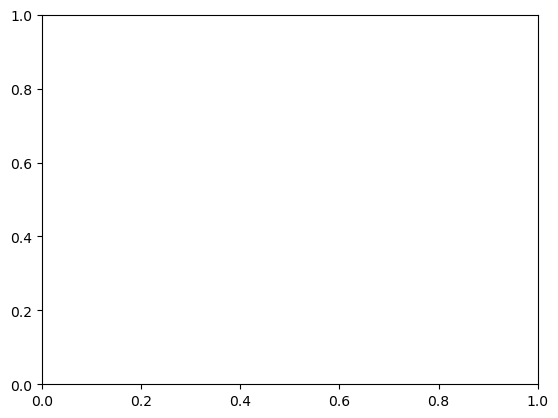

In [ ]:
from xgboost import plot_tree
plt.figure(figsize=(25, 15))

plot_tree(
    clf_2,
    tree_idx=0,
    rankdir='LR'
)

plt.show()

In [ ]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Using Lightgbm
# instantiate wrapper

clf_3 = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.1
)

clf_3.fit(X_train_resampled,
          y_train_resampled,
          eval_set=[(X_test, y_test)], 
          eval_metric='multi_logloss',
          callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
         )


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12643
[LightGBM] [Info] Number of data points in the train set: 301238, number of used features: 54
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[Ligh

,n_estimators,300
,class_weight,'balanced'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# get accuracy scoring
clf_score_3 = clf_3.score(X_test,y_test)
clf_score_3

# get recall score
y_preds_clf_3 = clf_3.predict(X_test)
recall_score_3= recall_score(y_test, y_preds_clf_3, average="weighted")

# print scores
print("===================================================================")
print(f"Recall scoring is {recall_score_3} /n and Accuracy is {clf_score_3}")

Recall scoring is 0.7868272561784269 /n and Accuracy is 0.7868272561784269


## CONCLUSION:
Random Forest performed the best out of all models tested. Random Forest will be used to test model on a real time scale.

This project is subject to further testing and improvement of model.

Model will be saved on Joblib and sent to the python script for real time testing.

In [ ]:
import joblib

joblib.dump(clf_1, "../data/random_forest_model.joblib")

['../data/random_forest_model.joblib']

© Tari Namikpoh. Unauthorized publication, reproduction, or distribution of this project is prohibited.